In [6]:
#Carga los datos:
#Carga la tabla consolidada de datos que se realizó en el avance de proyecto con empresa aliada anterior así como también los datos de alguna otra tabla que necesites usar para el EDA o la visualización y no fueron posibles consolidar en un solo archivo.
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

os.chdir('/Users/davidherrera/Downloads')


Apertura y lectura de los datos.

Se realiza observacíon y análisis de la informacón para entender resultados y posibles observaciónes para contestar las preguntas:

-¿Cómo maximizar ingresos?

-¿Cómo ganar mercado?

-¿Cómo optimizar precios?

In [7]:
df = pd.read_csv('df_final.csv')
df.sample(5)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,MONTH,WEEK_NUMBER,DATE,...,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,ID_CATEGORY,CATEGORY_NAME,SEGMENT,AVG_UNIT_PRICE
101809,07-23,7501071902109,1.246,142.025,4.282,TOTAL AUTOS AREA 5,2023,2,7,2023-02-20,...,CLOROX ROPA COLOR Q.MANCHAS LIQ. BOT. 3.8LT NA...,1,LIQUIDO,SAFE BLEACH,FABRIC TREATMENT,PRE LAVADOR,1,FABRIC TREATMENT and SANIT,PRETREAT,113.984751
110621,26-22,7501025406561,4.425,104.278,33.022,TOTAL AUTOS AREA 1,2022,7,26,2022-07-03,...,CLORALEX AROMA CLORO LIQUIDO LAVANDA BP 2L 750...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,1,FABRIC TREATMENT and SANIT,BLEACH,23.565650
41264,43-22,4008455425412,0.410,25.920,4.659,TOTAL AUTOS AREA 6,2022,10,43,2022-10-30,...,DR BECKMANN BLANQ INTENS SUPER BLANC PVO 6BSAS...,1,POLVO,CLORO,CLORO,NO DEFINIDO,1,FABRIC TREATMENT and SANIT,BLEACH,63.219512
72791,49-22,7501071903366,1.202,45.847,7.656,TOTAL AUTOS AREA 6,2022,12,49,2022-12-11,...,CLOROX AROMA PUREZA CITRICA BOT PLAST 3800ML N...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,1,FABRIC TREATMENT and SANIT,BLEACH,38.142263
79942,18-23,7501071903861,0.010,0.199,3.333,TOTAL AUTOS AREA 6,2023,5,18,2023-05-08,...,CLOROX PUREZA CITRICA BOT PLAS 1.89 LT 7501071...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,1,FABRIC TREATMENT and SANIT,BLEACH,19.900000


In [8]:
#Identificar las variables clave para el análisis:
#Determina qué variables son más relevantes para responder a las preguntas de negocio. 
df.describe().T


,count,mean,std,min,25%,50%,75%,max
TOTAL_UNIT_SALES,122002.0,3.211097,14.496009,0.000,0.063000,0.367000,1.520000,504.681
TOTAL_VALUE_SALES,122002.0,90.513761,350.236505,0.001,2.662000,16.812000,62.961500,12236.759
TOTAL_UNIT_AVG_WEEKLY_SALES,122002.0,10.099904,22.650142,0.042,2.316000,3.993500,8.898000,794.000
YEAR,122002.0,2022.334396,0.471781,2022.000,2022.000000,2022.000000,2023.000000,2023.000
MONTH,122002.0,5.531729,3.214612,1.000,3.000000,5.000000,8.000000,12.000
WEEK_NUMBER,122002.0,22.141194,14.134943,1.000,10.000000,20.000000,32.000000,52.000
CATEGORY,122002.0,1.000000,0.000000,1.000,1.000000,1.000000,1.000000,1.000
ID_CATEGORY,122002.0,1.000000,0.000000,1.000,1.000000,1.000000,1.000000,1.000
AVG_UNIT_PRICE,122002.0,55.088427,50.761249,0.000,20.905729,36.615289,69.293336,298.300


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122002 entries, 0 to 122001
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   WEEK                         122002 non-null  object 
 1   ITEM_CODE                    122002 non-null  object 
 2   TOTAL_UNIT_SALES             122002 non-null  float64
 3   TOTAL_VALUE_SALES            122002 non-null  float64
 4   TOTAL_UNIT_AVG_WEEKLY_SALES  122002 non-null  float64
 5   REGION                       122002 non-null  object 
 6   YEAR                         122002 non-null  int64  
 7   MONTH                        122002 non-null  int64  
 8   WEEK_NUMBER                  122002 non-null  int64  
 9   DATE                         122002 non-null  object 
 10  MANUFACTURER                 122002 non-null  object 
 11  BRAND                        122002 non-null  object 
 12  ITEM                         122002 non-null  object 
 13 

In [10]:
df['DATE'] = pd.to_datetime(df['DATE'])

In [11]:
df.shape[0]

122002

In [12]:
print(df.nunique())

WEEK                               80
ITEM_CODE                         350
TOTAL_UNIT_SALES                15197
TOTAL_VALUE_SALES               64425
TOTAL_UNIT_AVG_WEEKLY_SALES     26662
REGION                              7
YEAR                                2
MONTH                              12
WEEK_NUMBER                        52
DATE                               80
MANUFACTURER                       17
BRAND                              24
ITEM                              350
ITEM_DESCRIPTION                  350
CATEGORY                            1
FORMAT                              5
ATTR1                               4
ATTR2                               3
ATTR3                               8
ID_CATEGORY                         1
CATEGORY_NAME                       1
SEGMENT                             7
AVG_UNIT_PRICE                 101264
dtype: int64


In [13]:
print(df.isnull().sum())

WEEK                           0
ITEM_CODE                      0
TOTAL_UNIT_SALES               0
TOTAL_VALUE_SALES              0
TOTAL_UNIT_AVG_WEEKLY_SALES    0
REGION                         0
YEAR                           0
MONTH                          0
WEEK_NUMBER                    0
DATE                           0
MANUFACTURER                   0
BRAND                          0
ITEM                           0
ITEM_DESCRIPTION               0
CATEGORY                       0
FORMAT                         0
ATTR1                          0
ATTR2                          0
ATTR3                          0
ID_CATEGORY                    0
CATEGORY_NAME                  0
SEGMENT                        0
AVG_UNIT_PRICE                 0
dtype: int64


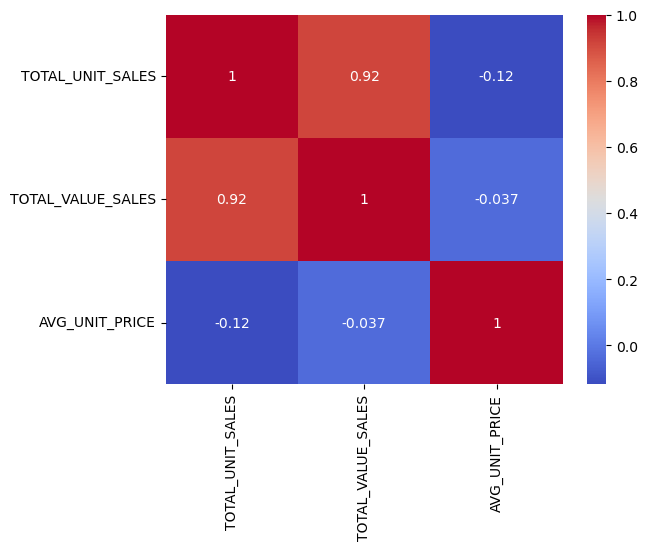

In [14]:
corr = df[['TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES', 'AVG_UNIT_PRICE']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [15]:
df.groupby('FORMAT')['TOTAL_VALUE_SALES'].mean().sort_values(ascending=False)

FORMAT
LIQUIDO    105.894050
GEL         84.112750
BARRA       66.924768
POLVO       52.655793
TOALLAS     26.859670
Name: TOTAL_VALUE_SALES, dtype: float64

Se genera un histograma en el cual, se puede ver que la distribución tiene un sesgo positivo hacia la derecha y que la mayoría de las transacciones son de montos bajos.

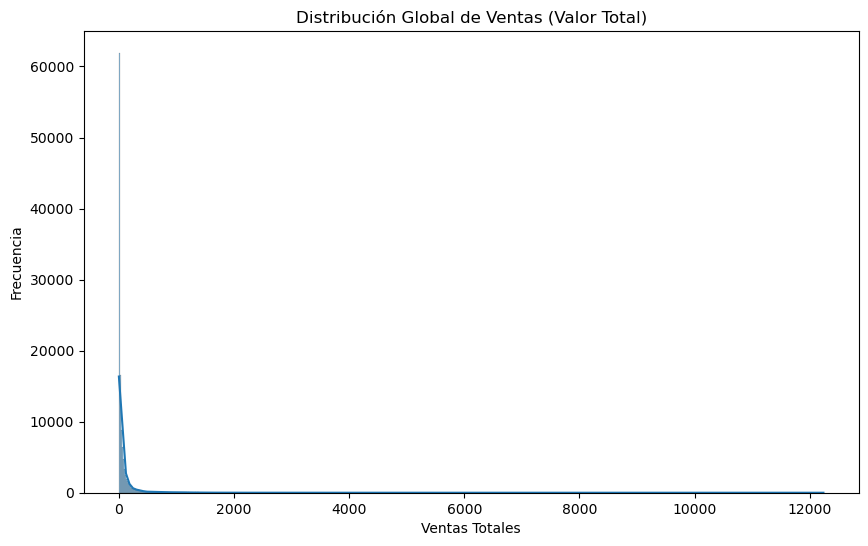

In [16]:
#Visualizar la distribución de ventas:
#Crea gráficos de distribución (histogramas o boxplots) para visualizar la distribución de ventas por diferentes categorías. Esto ayudará a identificar patrones de ventas y posibles outliers.
plt.figure(figsize=(10, 6))
sns.histplot(df['TOTAL_VALUE_SALES'], kde=True)
plt.title('Distribución Global de Ventas (Valor Total)')
plt.xlabel('Ventas Totales')
plt.ylabel('Frecuencia')
plt.show()

En los siguientes boxplot podemos identificar que la categoría dominante es FABRIC TREATMENT and SANIT.

También podemos notar que aunque hay compras por hasta $12,000, la gran mayoría se encuentra debajo de los $100.

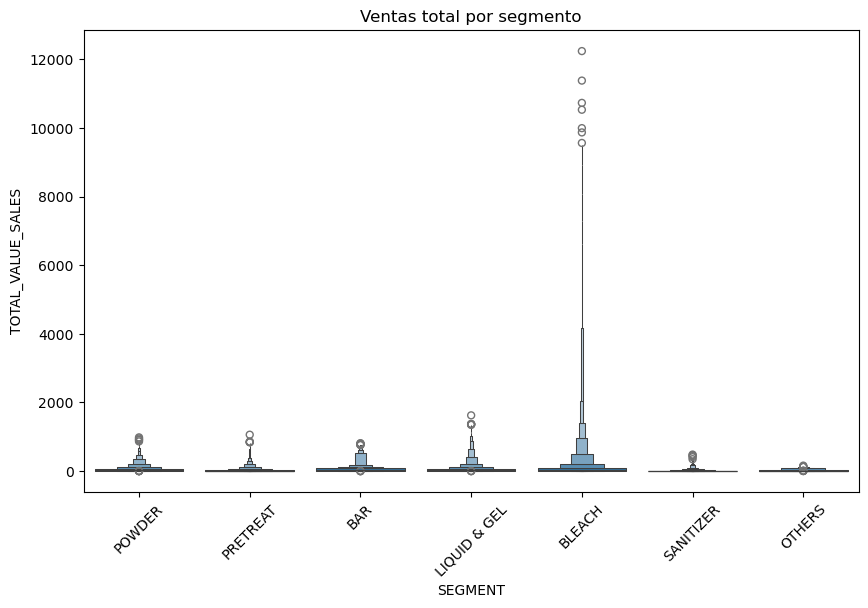

In [17]:
plt.figure(figsize=(10, 6))
sns.boxenplot(x='SEGMENT', y='TOTAL_VALUE_SALES', data=df)
plt.xticks(rotation=45)
plt.title('Ventas total por segmento')
plt.show()

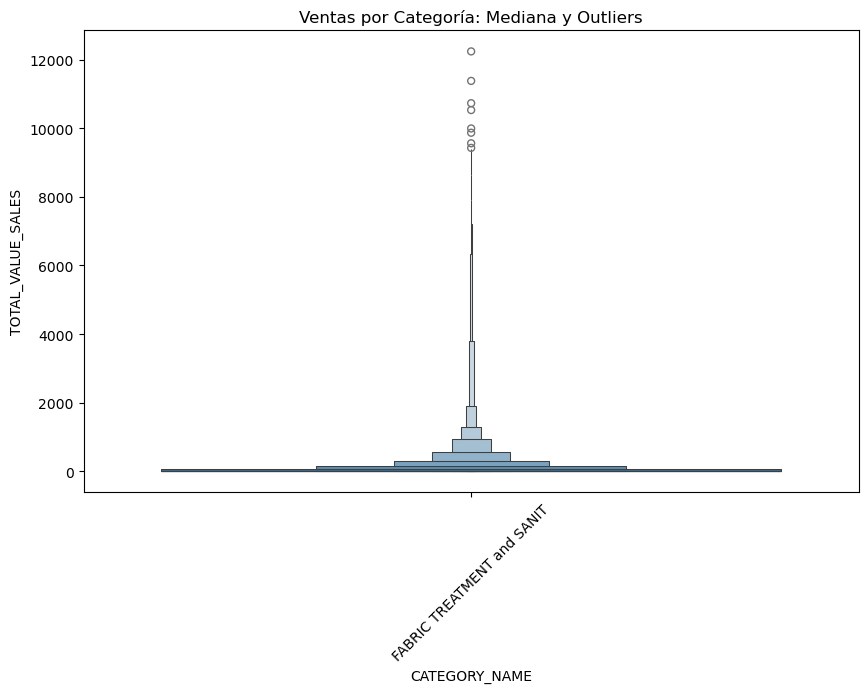

In [18]:
plt.figure(figsize=(10, 6));
sns.boxenplot(x='CATEGORY_NAME', y='TOTAL_VALUE_SALES', data=df)
plt.xticks(rotation=45);
plt.title('Ventas por Categoría: Mediana y Outliers');
plt.show();

En el siguiente Gráfico podemos observar que el segmento "BLEACH" domina la tendencia de ventas.

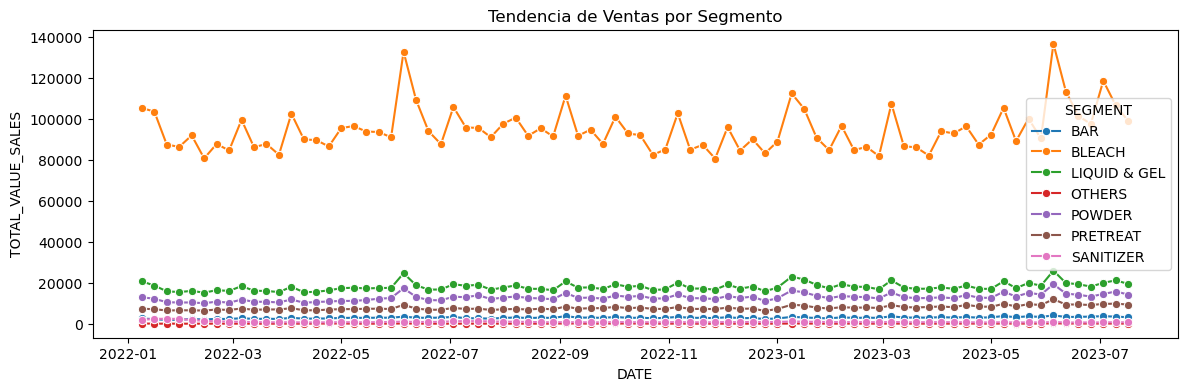

In [19]:
#Analizar la tendencia de ventas en el tiempo:
#Genera gráficos de líneas que muestren las tendencias de ventas a lo largo del tiempo. Filtra las ventas por diferentes productos, regiones o segmentos para analizar cómo han cambiado las ventas a lo largo del tiempo.
segment_trend = df.groupby(['DATE', 'SEGMENT'])['TOTAL_VALUE_SALES'].sum().reset_index()
plt.figure(figsize=(14, 4))
sns.lineplot(data=segment_trend, x='DATE', y='TOTAL_VALUE_SALES', hue='SEGMENT', marker='o')
plt.title('Tendencia de Ventas por Segmento')
plt.show()

En el siguiente gráfico podemos observar que la region "Total Autos Scanning México" muestra una gran cantidad de ventas, por lo podriamos habiar de una región de gran importancia logística.

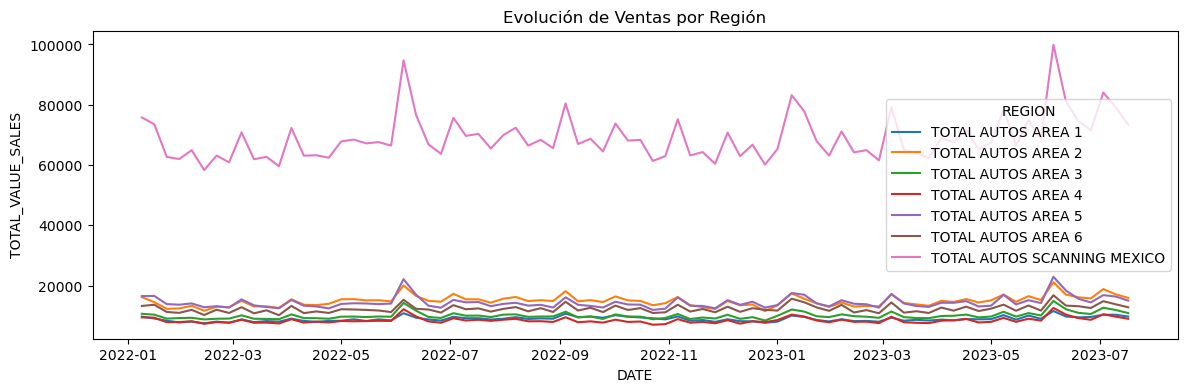

In [20]:
region_trend = df.groupby(['DATE', 'REGION'])['TOTAL_VALUE_SALES'].sum().reset_index()
plt.figure(figsize=(14, 4))
sns.lineplot(data=region_trend, x='DATE', y='TOTAL_VALUE_SALES', hue='REGION')
plt.title('Evolución de Ventas por Región')
plt.show()

En el siguiente gráfico onbsevamos el comportamiento en ventas de los 5 productos más importantes y podemos notar un comportamiento similar, con sus respectivas diferencias en ventas.

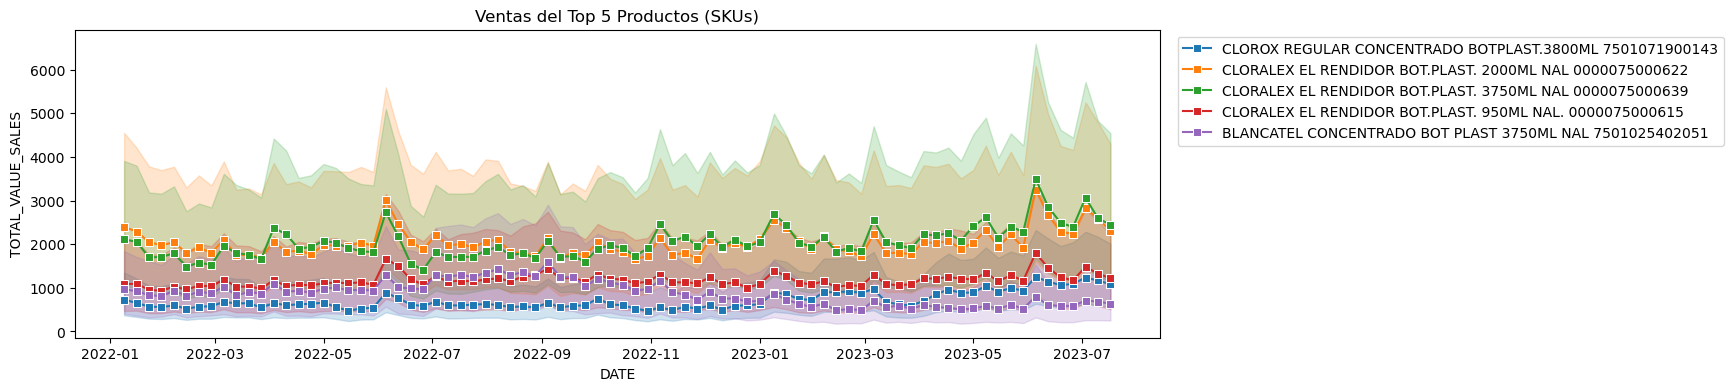

In [21]:
top_items = df.groupby('ITEM_DESCRIPTION')['TOTAL_VALUE_SALES'].sum().nlargest(5).index
df_top = df[df['ITEM_DESCRIPTION'].isin(top_items)]
plt.figure(figsize=(14, 4))
sns.lineplot(data=df_top, x='DATE', y='TOTAL_VALUE_SALES', hue='ITEM_DESCRIPTION', marker='s')
plt.title('Ventas del Top 5 Productos (SKUs)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

En el siguiente gráfico podemos observar la relación entre las "Unidades Vendidas" y el "Valor Total de Ventas", en donde podemos destacar varias lineas, lo que podría sugerir diferentes niveles de precios.

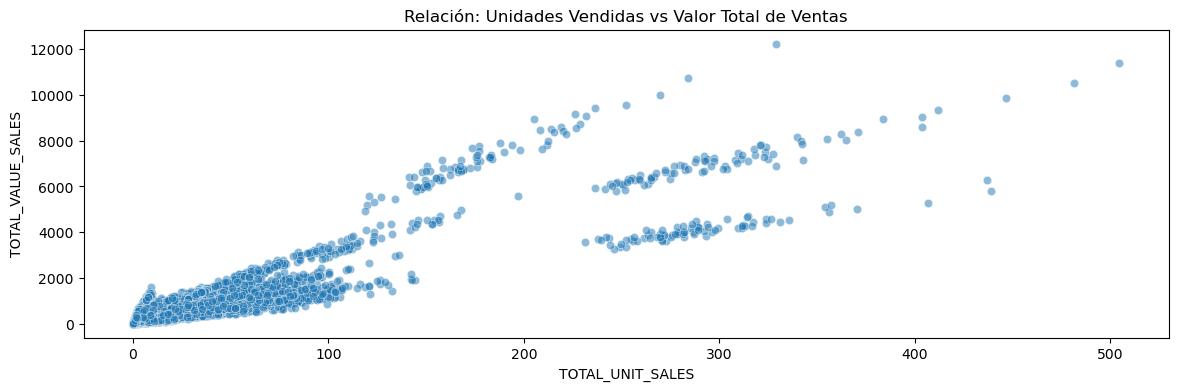

In [22]:
#Explorar la relación entre diferentes variables:
plt.figure(figsize=(14, 4))
sns.scatterplot(data=df, x='TOTAL_UNIT_SALES', y='TOTAL_VALUE_SALES', alpha=0.5)
plt.title('Relación: Unidades Vendidas vs Valor Total de Ventas')
plt.show()

En el siguiente gráfico podemos observar como el volumen de venta varía acorde al precio del producto. Podemos destacar como productos como el "Bleach" presentan una improtante caída en unidades vendidas cuando el precio sube de los $50.

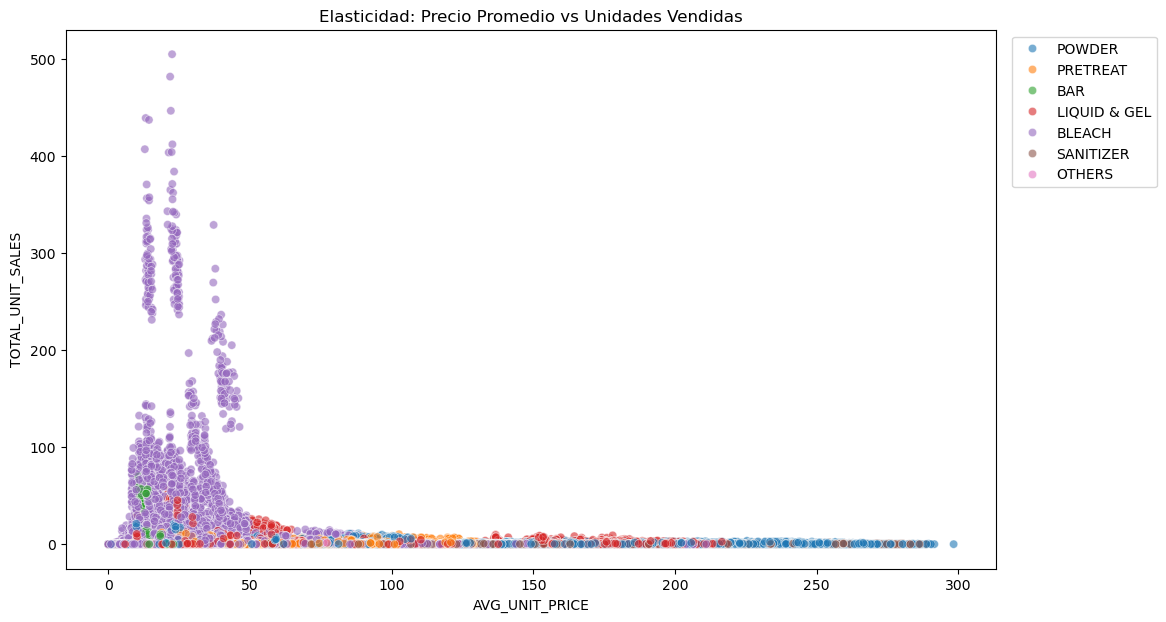

In [23]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='AVG_UNIT_PRICE', y='TOTAL_UNIT_SALES', hue='SEGMENT', alpha=0.6)
plt.title('Elasticidad: Precio Promedio vs Unidades Vendidas')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

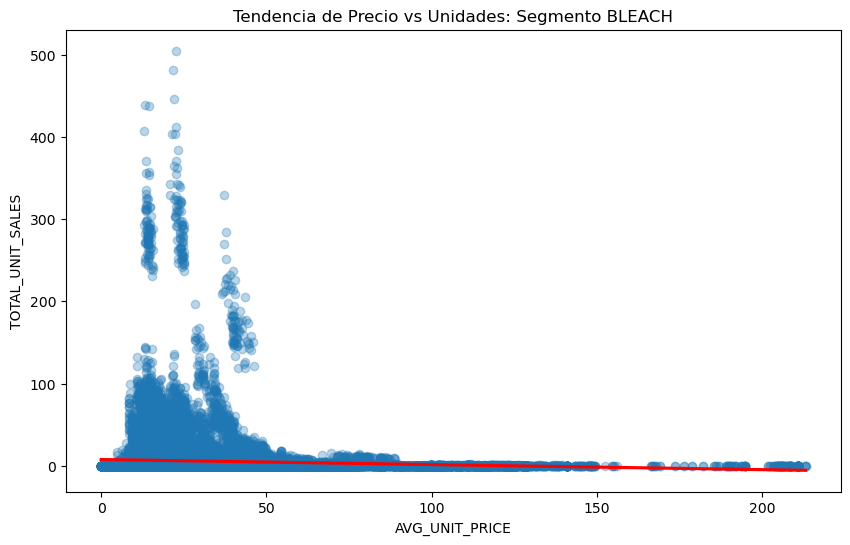

In [24]:
df_bleach = df[df['SEGMENT'] == 'BLEACH']
plt.figure(figsize=(10, 6))
sns.regplot(data=df_bleach, x='AVG_UNIT_PRICE', y='TOTAL_UNIT_SALES', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Tendencia de Precio vs Unidades: Segmento BLEACH')
plt.show()

En el siguiente gráfico podemos observar datos interesantes y muy relevantes apra el análisis:

1.-Podemos identificar la relevancia de la region "TOTAL AUTOS SCANNING MEXICO", representando más de 5 millones en ventas.

2.-Las areas  "Area 1" y "Area 4" presentan una gran opotunidad de crecimiento, lo que suguiere un enfoque para plan de mercado.

3.-El producto "BLEACH" es el componente más importante en todas las regiones, lo que nos habla de la necesidad de mantener el enfoque y cuidado en él, pero tambien habla de la necesidad de buscar diversificar los ingresos en otros porductos como los son "Poweder" o "Liquid and Gel" para evitar la dependencia.

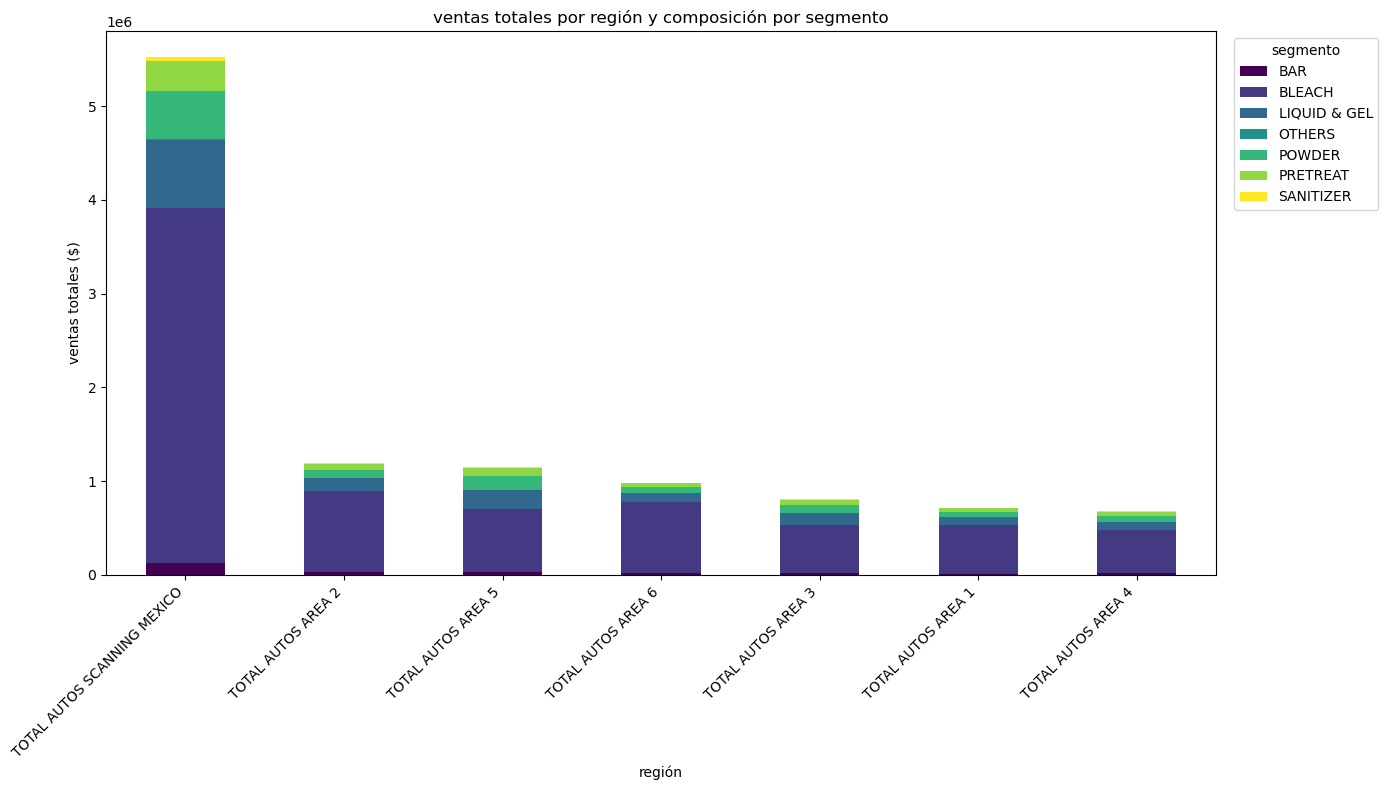

In [25]:
#Visualizar la distribución geográfica de las ventas:
#Si es posible, utiliza mapas o gráficos de barras apiladas para visualizar las ventas por región. Esto puede ayudar a identificar qué regiones tienen el mayor o menor rendimiento.
data_apilada = df.groupby(['REGION', 'SEGMENT'])['TOTAL_VALUE_SALES'].sum().unstack().fillna(0)
orden_regiones = data_apilada.sum(axis=1).sort_values(ascending=False).index
data_apilada = data_apilada.loc[orden_regiones]

ax = data_apilada.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis')

plt.title('ventas totales por región y composición por segmento')
plt.xlabel('región')
plt.ylabel('ventas totales ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='segmento', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

En el siguiente grupo de graficos podemos observar lo siguiente:

1.- Cualquier venta por encima de $150 se considera outlier.

2.-Más de 14000 registros son outliers, lo que sugiere ventas mayoristas de cloro, lo que requiere un enfoque de negocio diferente para ese producto.

3.-El valor máximo supera los $12000

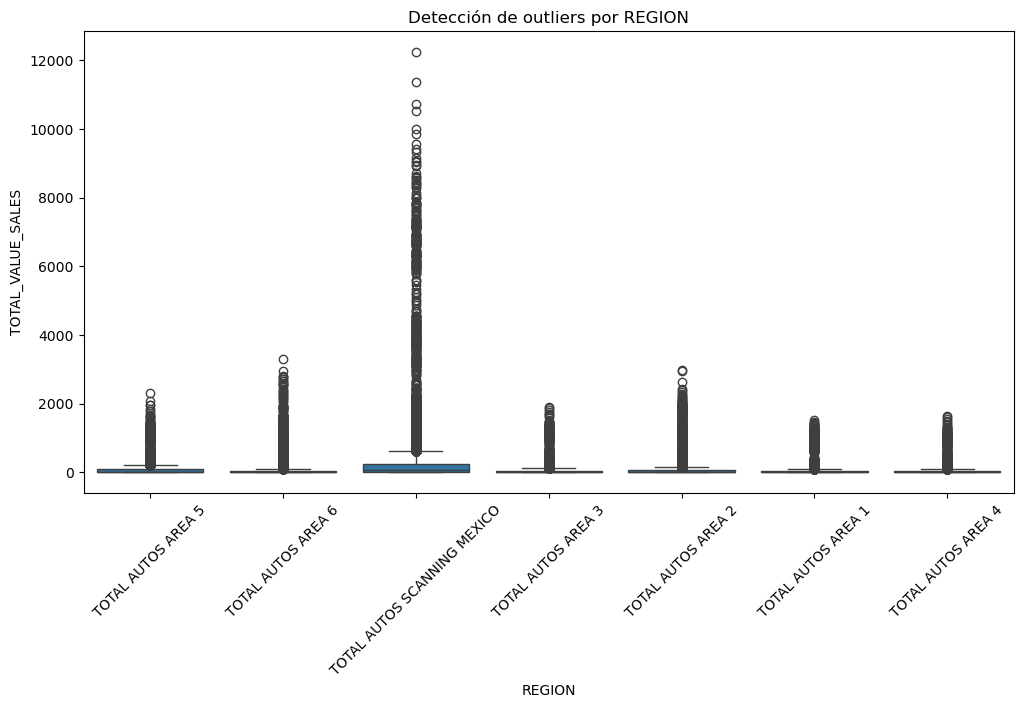

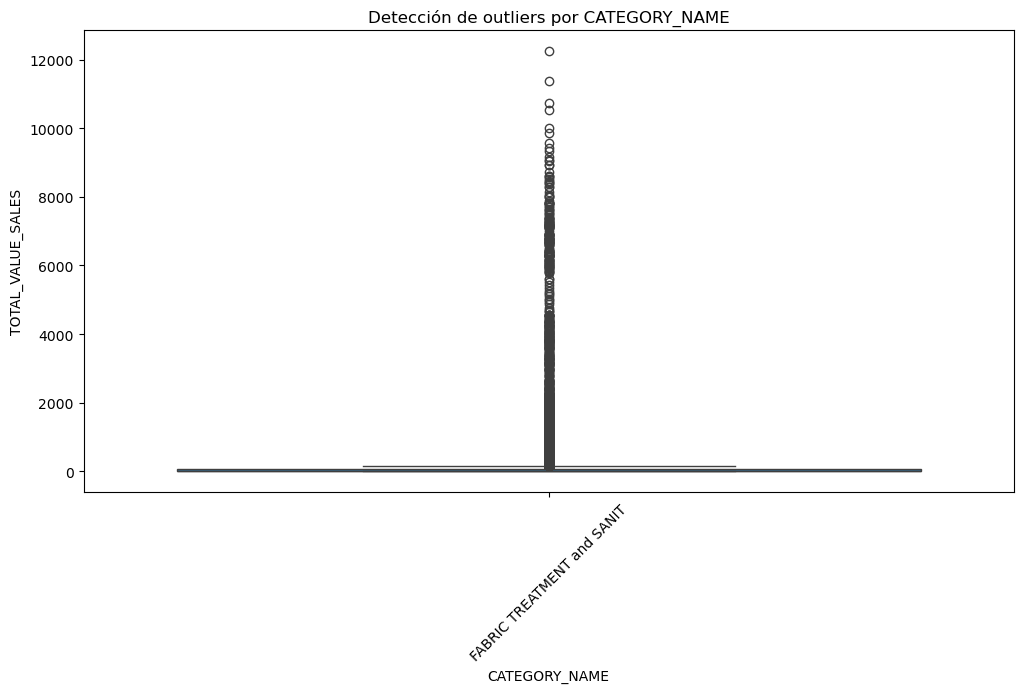

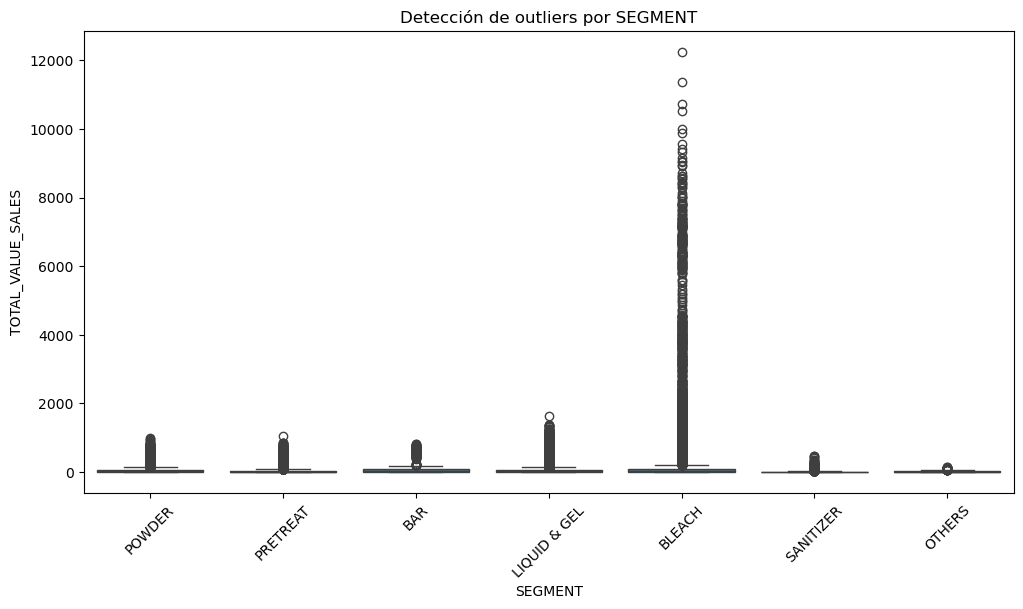

In [26]:
#Identificar posibles outliers y anomalías:
#Utiliza gráficos de caja (boxplots) para identificar posibles outliers en los datos de ventas por producto, categoría o región. Identificar outliers puede ayudar a entender mejor los patrones inusuales o anómalos en los datos.
dimensiones = ['REGION', 'CATEGORY_NAME', 'SEGMENT']

for dim in dimensiones:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=dim, y='TOTAL_VALUE_SALES')
    plt.xticks(rotation=45)
    plt.title(f'Detección de outliers por {dim}')
    plt.show()

In [27]:
#Documentar los insights obtenidos:
#Anota los principales hallazgos que observes en cada visualización. Por ejemplo, si ciertas categorías tienen un desempeño consistentemente alto o si ciertas regiones muestran un crecimiento o declive inesperado en las ventas.

*Se realizaron los comentarios a lo largo del documento*

In [28]:
#Guardar las visualizaciones:
#Guarda todas las visualizaciones generadas en archivos gráficos (PNG, JPEG) para usarlos posteriormente en el dashboard o en la presentación final.

*Se guardan gráficos*

Generación de un cambio en un archivo cualquiera de los notebook Python, commit y push. 

<Axes: xlabel='FORMAT'>

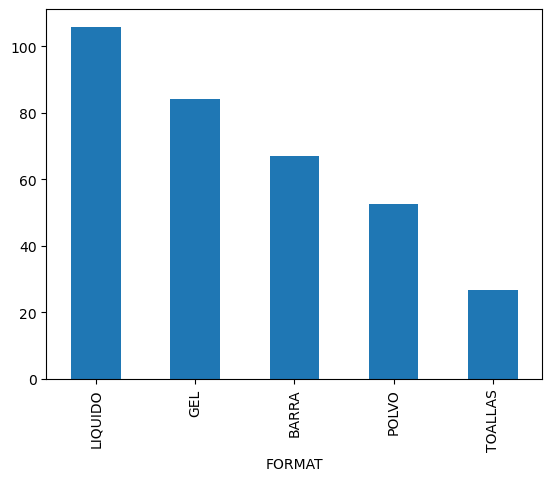

In [29]:
df.groupby('FORMAT')['TOTAL_VALUE_SALES'].mean().sort_values(ascending=False).plot.bar()

<Axes: xlabel='FORMAT'>

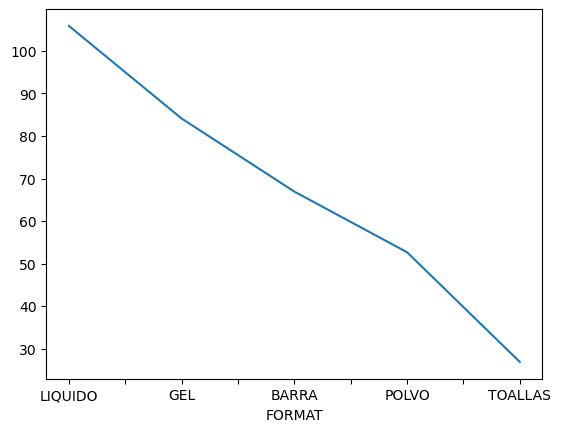

In [30]:
df.groupby('FORMAT')['TOTAL_VALUE_SALES'].mean().sort_values(ascending=False).plot.line()